In [ ]:
# python -m pip install matlabengine

# Start MATLAB engine
import matlab.engine
m = matlab.engine.start_matlab()

C:\Users\lsammon\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


RuntimeError: Could not find directory: C:\Program Files\MATLAB\R2023a\extern\engines\python\dist\matlab\engine\win64

In [ ]:
# Call a built in MATLAB function 
m.magic(3)

In [ ]:
# Call a custom MATLAB function 
base = 1.0
height = 1.0
area = m.triarea(base, height)
print(area)

In [2]:
# Call a MATLAB app 
# # Access Data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

# Work with a smaller dataset for this demo 
print(housing.data.shape)

(20640, 8)


In [3]:
from sklearn.model_selection import train_test_split

housing.data = housing.data[0:2001,:]
housing.target = housing.target[0:2001]

print(housing.data.shape)
print(housing.target.shape)

(2001, 8)
(2001,)


In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

# Randomly sample for training and testing data 
indices = np.arange(housing.data.shape[0])
#train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)

# Assign train and test indices 
train_indices = np.arange(1600)
test_indices = np.arange(1601, 2001)

print(train_indices.shape)
print(test_indices.shape)

(1600,)
(400,)


In [5]:
# Train data
x_train = housing.data[train_indices.tolist(), :].tolist()
y_train = housing.target[train_indices.tolist()].tolist()

# Test data
x_test = housing.data[test_indices.tolist(), :].tolist()
y_test = housing.target[test_indices.tolist()].tolist()

In [6]:
#Preprocess Data
X_ml = matlab.double(x_train)
y_ml = matlab.double(y_train)

In [7]:
# AI modeling (Training using MATLAB Regression Learner)
m.regressionLearner(X_ml, y_ml, nargout=0)

In [9]:
# Import the model from MATLAB 
model = m.workspace['trainedModel']
model

{'predictFcn': <matlab.object at 0x247ff3a25b0>,
 'RegressionEnsemble': <matlab.object at 0x247ff8fb850>,
 'About': 'This struct is a trained model exported from Regression Learner R2024a.',
 'HowToPredict': 'To make predictions on a new predictor column matrix, X, use: \n  yfit = c.predictFcn(X) \nreplacing \'c\' with the name of the variable that is this struct, e.g. \'trainedModel\'. \n \nX must contain exactly 8 columns because this model was trained using 8 predictors. \nX must contain only predictor columns in exactly the same order and format as your training \ndata. Do not include the response column or any columns you did not import into the app. \n \nFor more information, see <a href="matlab:helpview(fullfile(docroot, \'stats\', \'stats.map\'), \'appregression_exportmodeltoworkspace\')">How to predict using an exported model</a>.'}

In [10]:
predFcn = model.get('predictFcn')

In [11]:
x_test = matlab.double(x_test)
print(x_test.size)

(400, 8)


In [12]:
y_pred = m.feval(predFcn, x_test)
# print(y_test)

In [13]:
# Compare to true values 
# Import libraries 
import seaborn as sns
import numpy as np
import pandas as pd


In [14]:
# Prep data
y_pred_np = np.array(y_pred) 
y_true_np = np.array(y_test)

n = y_true_np.size

x = np.arange(n)

y_true_np = y_true_np.flatten()
y_pred_np = y_pred_np.flatten()

print(y_pred_np.shape)

(400,)


In [15]:
my_dict = dict(x=x,y=y_true_np)
data_true = pd.DataFrame (my_dict)

my_dict_pred = dict(x=x,y=y_pred_np)
data_pred = pd.DataFrame (my_dict_pred)

<Axes: xlabel='x', ylabel='y'>

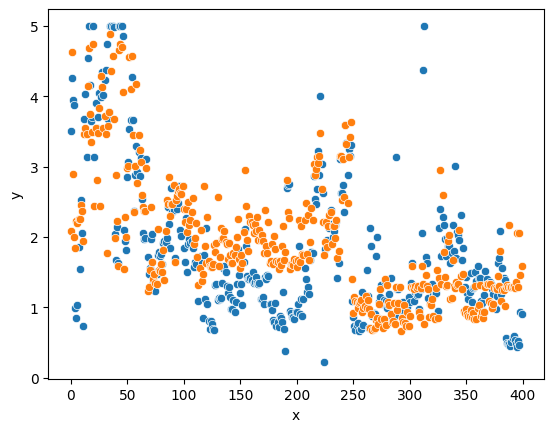

In [16]:
# Plot using seaborn
sns.scatterplot(data=data_true, x="x", y="y")
sns.scatterplot(data=data_pred, x="x", y="y")